# Variant regulatory consequence analysis

This notebook introduces new dataset `Epiraction`, which contains the regulatory consequences for variants.


## Epiraction dataset ingesion


In [30]:
from __future__ import annotations

from pathlib import Path

import hail as hl
import pandas as pd
import plotnine as p9
from gentropy.common.session import Session
from pyspark.sql import functions as f
import plotnine as p9
import pandas as pd
from manuscript_methods import group_statistics, plot_group_statistics
from pyspark.sql import Window


In [2]:
hail_home = Path(hl.__file__).parent.as_posix()
session = Session(
    extended_spark_conf={"spark.driver.memory": "40G"},
    start_hail=True,
    hail_home=hail_home,
)
dataset_path = "../../data/intermediate_files/epiraction"


25/12/18 13:50:24 WARN Utils: Your hostname, mindos resolves to a loopback address: 127.0.1.1; using 192.168.0.100 instead (on interface eno1)
25/12/18 13:50:24 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
25/12/18 13:50:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
pip-installed Hail requires additional configuration options in Spark referring
  to the path to the Hail Python module directory HAIL_DIR,
  e.g. /path/to/python/site-packages/hail:
    spark.jars=HAIL_DIR/backend/hail-all-spark.jar
    spark.driver.extraClassPath=HAIL_DIR/backend/hail-all-spark.jar
    spark.executor.extraClassPath=./hail-all-spark.jarRunning on Apache Spark version 3.5.1
SparkUI available at http://192.168.0.100:4040
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
  

In [3]:
session.spark


In [4]:
epiraction = session.spark.read.parquet(dataset_path)
epiraction.printSchema()


root
 |-- chromosome: string (nullable = true)
 |-- start: string (nullable = true)
 |-- end: string (nullable = true)
 |-- geneId: string (nullable = true)
 |-- biosampleName: string (nullable = true)
 |-- intervalType: string (nullable = true)
 |-- score: double (nullable = true)
 |-- resourceScore: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- name: string (nullable = true)
 |    |    |-- value: float (nullable = true)
 |-- datasourceId: string (nullable = true)
 |-- pmid: string (nullable = true)



In [5]:
# Show all chromosomes
epiraction.select("chromosome").distinct().orderBy("chromosome").show()


+----------+
|chromosome|
+----------+
|      chr1|
|     chr10|
|     chr11|
|     chr12|
|     chr13|
|     chr14|
|     chr15|
|     chr16|
|     chr17|
|     chr18|
|     chr19|
|      chr2|
|     chr20|
|     chr21|
|     chr22|
|      chr3|
|      chr4|
|      chr5|
|      chr6|
|      chr7|
+----------+
only showing top 20 rows



No mitochondrial chromosome found


In [7]:
epiraction.select("geneId").distinct().count()


24857

In [8]:
epiraction.select("biosampleName").distinct().count()


78

In [6]:
epiraction.select("intervalType").distinct().orderBy("intervalType").show()


+------------+
|intervalType|
+------------+
|    enhancer|
|    promoter|
+------------+



In [16]:
epiraction.groupBy("intervalType").count().select(
    "intervalType",
    f.format_number("count", 0).alias("count"),
).orderBy("count", ascending=False).show()


+------------+-----------+
|intervalType|      count|
+------------+-----------+
|    enhancer|250,726,289|
|    promoter|  1,051,129|
+------------+-----------+



## Describe EPIraction score distribution

In [17]:
epiraction.select("score").describe().show()


+-------+--------------------+
|summary|               score|
+-------+--------------------+
|  count|           251777418|
|   mean|0.004735535229663087|
| stddev|0.020850645747324287|
|    min|           8.2381E-6|
|    max|                 1.0|
+-------+--------------------+



/home/mindos/Projects/OpenTargets/gentropy-manuscript/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 4 x 4 in image.
/home/mindos/Projects/OpenTargets/gentropy-manuscript/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: plots/05_epiraction_score_vs_interval_type_boxplot.png


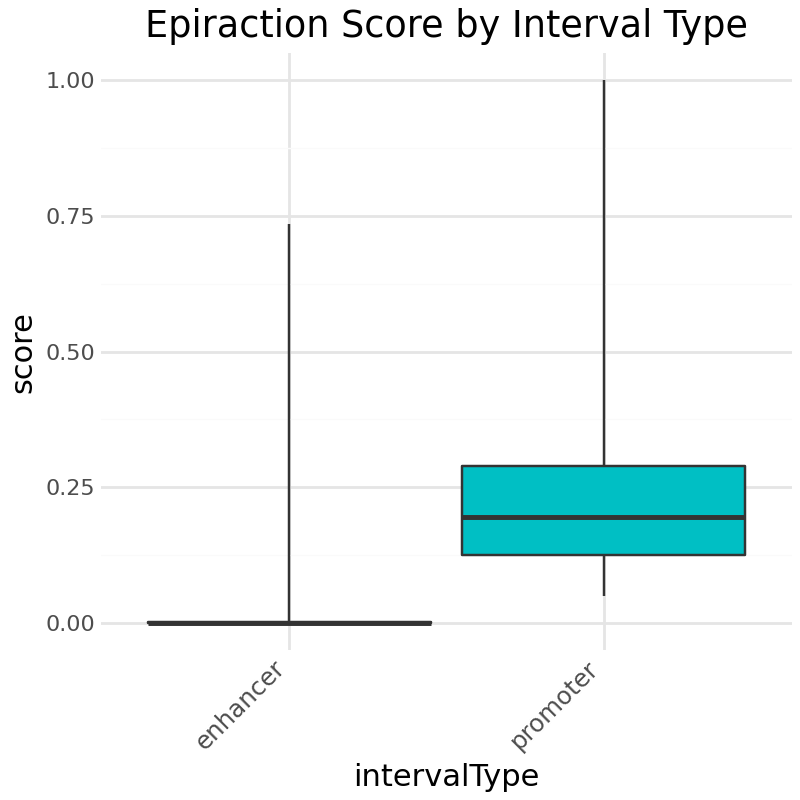

In [24]:
_data = (
    epiraction.select("score", "intervalType")
    .groupBy("intervalType")
    .agg(
        f.avg("score").alias("avg"),
        f.min("score").alias("min"),
        f.max("score").alias("max"),
        f.approx_percentile("score", 0.25).alias("Q1"),
        f.approx_percentile("score", 0.50).alias("Q2"),
        f.approx_percentile("score", 0.75).alias("Q3"),
    )
)
plot = (
    p9.ggplot(
        data=_data.toPandas(),
        mapping=p9.aes(
            lower="Q1",
            middle="Q2",
            upper="Q3",
            ymax="max",
            ymin="min",
            x="intervalType",
            fill="intervalType",
        ),
    )
    + p9.geom_boxplot(stat="identity")
    + p9.labs(y="score", title="Epiraction Score by Interval Type")
    + p9.theme_minimal()
    + p9.theme(
        figure_size=(4, 4),
        legend_position="none",
        axis_text_x=p9.element_text(rotation=45, hjust=1),
        axis_text_y=p9.element_text(size=8),
    )
)
plot.save("plots/05_epiraction_score_vs_interval_type_boxplot.png")
plot


/home/mindos/Projects/OpenTargets/gentropy-manuscript/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 4 in image.
/home/mindos/Projects/OpenTargets/gentropy-manuscript/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: plots/05_epiraction_score_distribution_by_interval_type_histogram.png
/home/mindos/Projects/OpenTargets/gentropy-manuscript/.venv/lib/python3.11/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 1089255 rows containing non-finite values.
/home/mindos/Projects/OpenTargets/gentropy-manuscript/.venv/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_histogram : Removed 4 rows containing missing values.
/home/mindos/Projects/OpenTargets/gentropy-manuscript/.venv/lib/python3.11/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 1089255 rows containing non-finite values.
/home/mindos/Projects/OpenTargets/gentropy-manuscript/.venv/lib/pyt

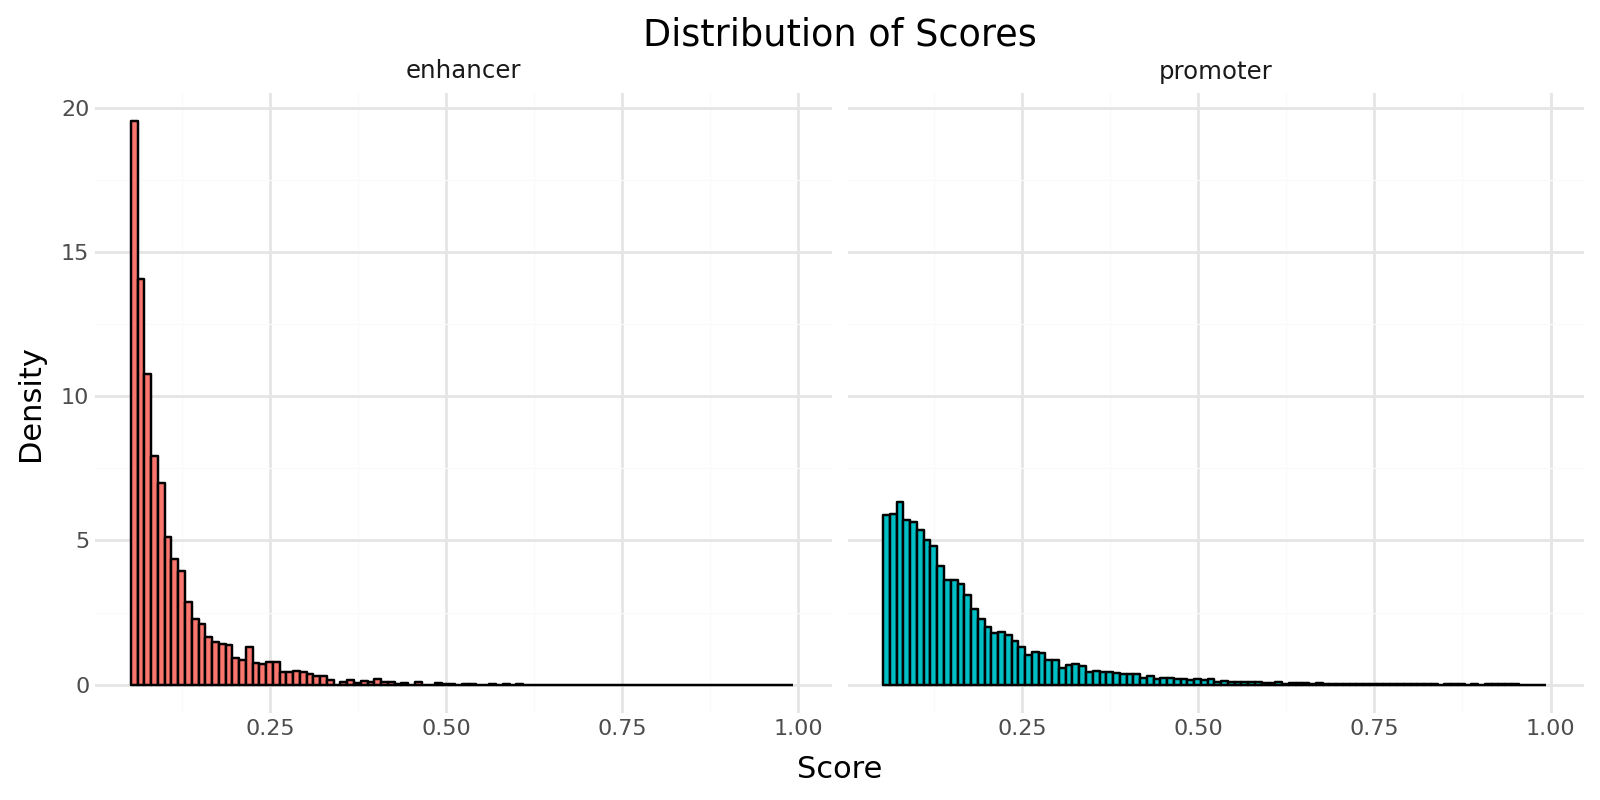

In [28]:
_data = epiraction.drop_duplicates(["start", "end", "intervalType"]).select("score", "intervalType")

plot = (
    p9.ggplot(_data.toPandas(), p9.aes(x="score", fill="intervalType", y=p9.after_stat("density")))
    + p9.theme_minimal()
    + p9.geom_histogram(bins=100, color="black")
    + p9.labs(title="Distribution of Scores", x="Score", y="Density")
    + p9.facet_grid(cols="intervalType", scales="free")
    + p9.xlim(0.05, 1.00)
    + p9.theme(
        figure_size=(8, 4),
        axis_text_x=p9.element_text(size=8),
        axis_text_y=p9.element_text(size=8),
        legend_position="none",
    )
)
plot.save("plots/05_epiraction_score_distribution_by_interval_type_histogram.png")
plot


In [ ]:
# Check amount of genes associated with intervals
epiraction.groupBy("intervalType").agg(f.countDistinct("geneId").alias("num_genes")).show()


+------------+---------+
|intervalType|num_genes|
+------------+---------+
|    enhancer|    24855|
|    promoter|    24857|
+------------+---------+



In [31]:
# There are 2 genes not associated with any enhancer
w = Window().partitionBy("geneId")
promoter_only_genes = (
    epiraction.groupBy("geneId")
    .agg(f.count_distinct("intervalType").alias("num_interval_types"))
    .filter(f.col("num_interval_types") == 1)
    .show()
)


+---------------+------------------+
|         geneId|num_interval_types|
+---------------+------------------+
|ENSG00000261600|                 1|
|ENSG00000286698|                 1|
+---------------+------------------+



In [38]:
session.spark.stop()
